In [12]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt

Problem 1



In [2]:
p1 = np.array([[0.9,0.1,0],
               [0,0.75,0.25],
               [0.5,0,0.5]])
p1_50 = np.linalg.matrix_power(p1,50)
print(p1_50.round(3))

[[0.625 0.25  0.125]
 [0.625 0.25  0.125]
 [0.625 0.25  0.125]]


Problem 2

In [6]:
p2 = np.array([[0.5,0.5,0,0,0,0],
             [1/3,0,1/3,0,1/3,0],
             [0,0,1/4,3/4,0,0],
             [0,0,1,0,0,0],
             [0,0,0,0,0,1],
             [0,0,0,0,1,0]])
p2_20 = np.linalg.matrix_power(p2,20)
p2_21 = np.linalg.matmul(p2,p2_20)
print(p2_20.round(3))
print(p2_21.round(3))



[[0.001 0.001 0.285 0.213 0.312 0.187]
 [0.001 0.    0.285 0.215 0.062 0.437]
 [0.    0.    0.573 0.427 0.    0.   ]
 [0.    0.    0.57  0.43  0.    0.   ]
 [0.    0.    0.    0.    1.    0.   ]
 [0.    0.    0.    0.    0.    1.   ]]
[[0.001 0.001 0.285 0.214 0.187 0.312]
 [0.    0.    0.286 0.214 0.437 0.062]
 [0.    0.    0.57  0.43  0.    0.   ]
 [0.    0.    0.573 0.427 0.    0.   ]
 [0.    0.    0.    0.    0.    1.   ]
 [0.    0.    0.    0.    1.    0.   ]]


Problem 4

[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1]
[[ 0  0  0 ...  0  0  0]
 [10 10 10 ... 10 10 10]]
[ True  True  True ...  True  True  True]
[ True  True False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[1.     1.     1.     ... 0.0571 0.0571 0.0571]


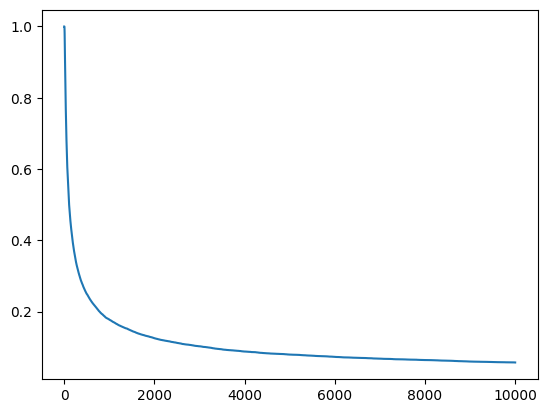

In [7]:
start1 = [0, 10] #[lamb, lion]
R = 2*10**4
T = 10**4
positions1 = np.array([start1] * R)
isAlive1 = np.array([True] * R)
S_1 = np.zeros(T)
print([np.random.randint(0,2)*2 - 1]*10)
positions1 = np.transpose(positions1) #makes the following code cleaner, will transpose back in the end
print(positions1)
for i in range(T):
  positions1[0] = positions1[0] + ((np.random.randint(0,2,R))*2 -1)*isAlive1 #lamb stops moving when dead
  positions1[1] = positions1[1] + ((np.random.randint(0,2,R))*2 -1)*isAlive1 #lion stops moving if lamb dies
  isAlive1 = (positions1[1]-positions1[0] != 0)
  if i%1000 == 0:
    print(isAlive1)
  S_1[i] = np.sum(isAlive1)/R

print(S_1)
plt.plot(S_1)

[-0.49057337  1.65082228]
[1.05262544e+22 1.71928824e+22 2.80817084e+22 ...            inf
            inf            inf]


/tmp/ipykernel_39538/2636545654.py:11: RuntimeWarning: overflow encountered in exp
  print(np.exp(fit1[1] + beta1*np.linspace(10**2, 10**4, 10**4-10**2)))
/tmp/ipykernel_39538/2636545654.py:13: RuntimeWarning: divide by zero encountered in divide
  ax1.plot(scp.special.erf(10/(2*(np.linspace(0,10**4,10**4))**(0.5))), label="Continuum prediction", linestyle="--")


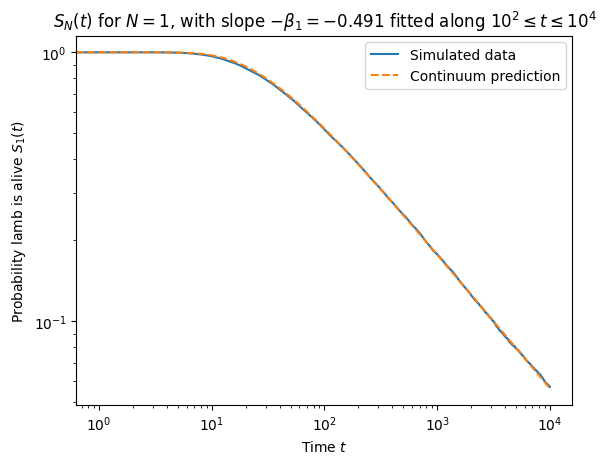

In [28]:
fig1, ax1 = plt.subplots()
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Time $t$')
ax1.set_ylabel("Probability lamb is alive $S_1(t)$")
ax1.plot(S_1, label="Simulated data")
#axb
fit1 = np.polyfit(np.log(np.linspace(10**2, 10**4, 10**4-10**2)), np.log(S_1[10**2:10**4]), 1)
print(fit1)
beta1 = -fit1[0]
print(np.exp(fit1[1] + beta1*np.linspace(10**2, 10**4, 10**4-10**2)))
ax1.set_title('$S_N(t)$ for $N=1$, with slope $-\\beta_1 = ' + str(-beta1.round(3)) + '$ fitted along $10^2 \\leq t \\leq 10^4$')
ax1.plot(scp.special.erf(10/(2*(np.linspace(0,10**4,10**4))**(0.5))), label="Continuum prediction", linestyle="--")

ax1.legend()


[ True  True  True ...  True  True  True]
[ True False False ... False False False]
[ True False False ... False False False]
[ True False False ... False False False]
[ True False False ... False False False]
[ True False False ... False False False]
[ True False False ... False False False]
[ True False False ... False False False]
[ True False False ... False False False]
[ True False False ... False False False]
[1.     1.     1.     ... 0.0117 0.0117 0.0117]


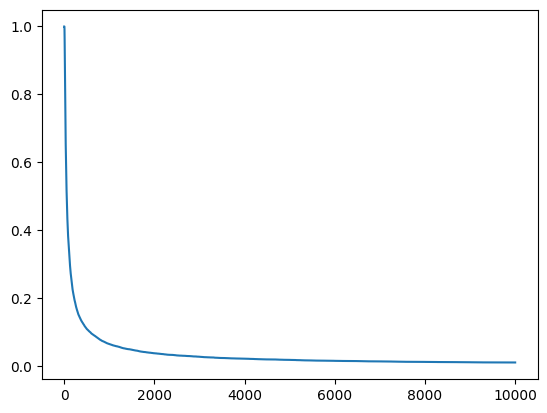

In [9]:
start2 = [0, 10, 10] #[lamb, lion, lion]
R = 2*10**4
T = 10**4
positions2 = np.array([start2] * R)
isAlive2 = np.array([True] * R)
S_2 = np.zeros(T)
positions2 = np.transpose(positions2) #makes the following code cleaner, will transpose back in the end
for i in range(T):
  positions2[0] = positions2[0] + ((np.random.randint(0,2,R))*2 -1)*isAlive2 #lamb stops moving when dead
  positions2[1] = positions2[1] + ((np.random.randint(0,2,R))*2 -1)*isAlive2 #lion stops moving if lamb dies
  positions2[2] = positions2[2] + ((np.random.randint(0,2,R))*2 -1)*isAlive2 #lion stops moving if lamb dies
  isAlive2 = np.logical_and((positions2[1]-positions2[0] != 0), (positions2[2] - positions2[0] != 0))
  if i%1000 == 0:
    print(isAlive2)
  S_2[i] = np.sum(isAlive2)/R

print(S_2)
plt.plot(S_2)

[-0.76087093  2.52657971]
[1.38510943e+34 2.96455500e+34 6.34504838e+34 ...            inf
            inf            inf]


/tmp/ipykernel_39538/152143310.py:13: RuntimeWarning: overflow encountered in exp
  print(np.exp(fit2[1] + beta2*np.linspace(10**2, 10**4, 10**4-10**2)))


Text(0.5, 1.0, '$S_N(t)$ for $N=2$, with slope $-\\beta_2 = -0.761$ fitted along $10^2 \\leq t \\leq 10^4$')

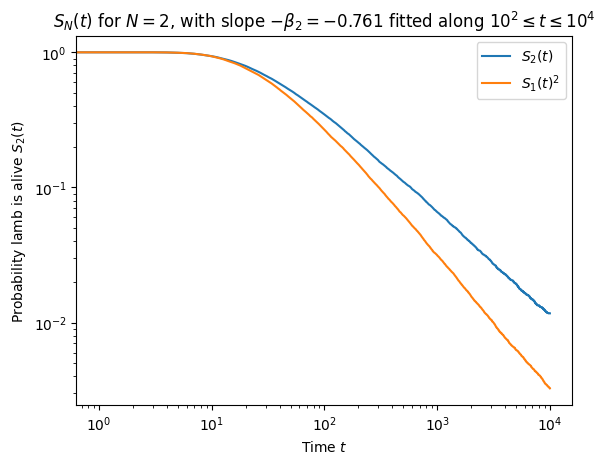

In [29]:
fig2, ax2 = plt.subplots()
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Time $t$')
ax2.set_ylabel("Probability lamb is alive $S_2(t)$")
ax2.plot(S_2, label="$S_2(t)$")
ax2.plot(S_1**2, label = "$S_1(t)^2$")
ax2.legend()

fit2 = np.polyfit(np.log(np.linspace(10**2, 10**4, 10**4-10**2)), np.log(S_2[10**2:10**4]), 1)
print(fit2)
beta2 = -fit2[0]
print(np.exp(fit2[1] + beta2*np.linspace(10**2, 10**4, 10**4-10**2)))
ax2.set_title('$S_N(t)$ for $N=2$, with slope $-\\beta_2 = ' + str(-beta2.round(3)) + '$ fitted along $10^2 \\leq t \\leq 10^4$')